Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


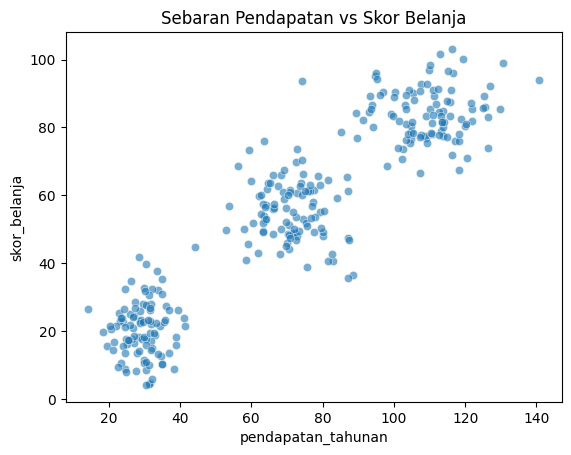

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20],  [6, 8],   (100, 2))   # hemat
grp2 = np.random.normal([70, 55],  [8, 10],  (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8],  (100, 2))   # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


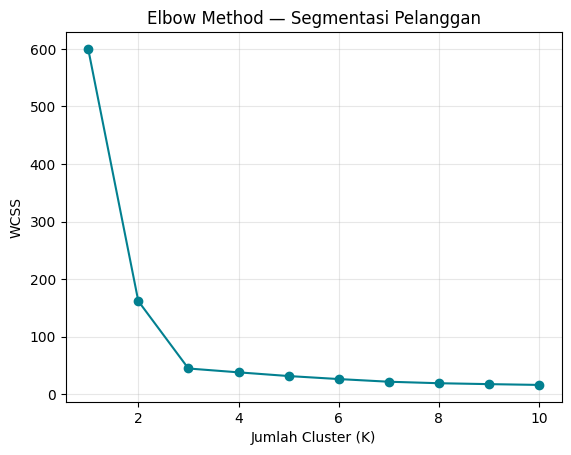

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Pembanding objektif: Silhouette Score untuk kandidat K
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    print(f'K={k}: Silhouette = {sil:.3f}')

K=2: Silhouette = 0.634
K=3: Silhouette = 0.695
K=4: Silhouette = 0.580
K=5: Silhouette = 0.481
K=6: Silhouette = 0.381
K=7: Silhouette = 0.394


In [5]:
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print()
print('Karakteristik rata-rata tiap cluster:')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))
print()
print('Jumlah anggota tiap cluster:')
print(df['cluster'].value_counts().sort_index())

WCSS akhir      : 44.556
Silhouette Score: 0.695

Karakteristik rata-rata tiap cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08

Jumlah anggota tiap cluster:
cluster
0     99
1    100
2    101
Name: count, dtype: int64


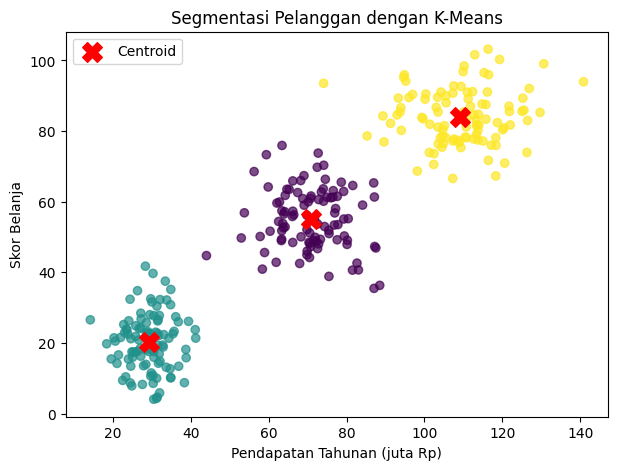

In [6]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()

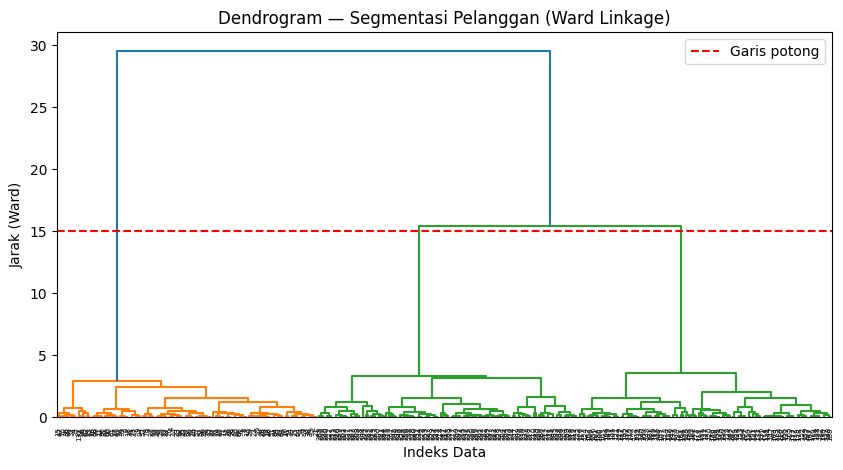

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--', label='Garis potong')
plt.legend()
plt.show()